# Proiect licenta
Pentru inceput am incarcat datasetul pe drive si apoi am dat mount pentru a avea acces si in colab la setul de date. Pentru asta am folosit explicatiile de pe:
https://www.geeksforgeeks.org/data-science/how-to-load-a-dataset-from-the-google-drive-to-google-colab/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Am folosit modulul os pentru a lucra cu fisiere, directoare, mai precis cu calea setului de date.

 Pentru a sorta fisierele npy, am folosit modulul glob (global), care poate cauta anumite patternuri in denumirea fisierelor:
 https://builtin.com/software-engineering-perspectives/glob-in-python


Am salvat calea catre folderul principal intr-un string numit data_root.

Am contruit apoi un pattern pentru calea fisierelor npy, folosind data_root de mai sus + directorul care incepe cu LIDC-IDRI- + fisierul care se termina cu .npy.

Folosind glob, am cautat fiecare fisier a carui cale se potrivea cu patternul creat mai sus si l-am adaugat intr-o lista de stringuri sortata. (ele apar sortate datorita formatului 0001, 0002, etc)

In [ ]:
import os
import glob
data_root = "/content/drive/MyDrive/ScoalaDeVara/LIDC-IDRI"
pattern = os.path.join(data_root, 'LIDC-IDRI-*', '*.npy')
image_paths = sorted(glob.glob(pattern))

Impart imaginile in seturi de antrenare, validare, respectiv testare:

In [ ]:
length = len(image_paths)
max_train = int(0.6 * length)
max_val = int(0.7 * length)
train_paths = image_paths[:max_train]
val_paths = image_paths[max_train:max_val]
test_paths = image_paths[max_val:]

Debug sa verific corectitudinea impartirii setului:

In [ ]:
print("total:", length)

print("\ntrain:", len(train_paths))
print("val:", len(val_paths))
print("test:", len(test_paths))

print("\nsum:", len(train_paths) + len(val_paths) + len(test_paths))


total: 1359

train: 815
val: 136
test: 408

sum: 1359


Cum avem tensori, am folosit biblioteca NumPy pentru a lucra.

Am salvat stringul cu calea catre prima imagine din setul de date, adica prima imagine din lista de stringuri creata mai sus: image_paths[0] cu numele sample_path.

Cu calea obtinuta am incarcat obiectul NumPy array corespunzator. Obiectul este sub forma unei matrice 2x2, deoarece imaginile sunt 2d si grayscale.

Am afisat cu niste printuri cateva detalii despre imaginea luata ca sample:

*   calea (care corespunde cu cea de pe drive)
*   tipul (care este numpy.ndarray)
*   forma (care e (512,512) - nr de pixeli; daca imaginea ar fi fost colorata, forma ar fi fost (512, 512, x) dar nu este cazul)
*   tipul datelor (tipul pixelilor mai precis, care este float64)

In [ ]:
import numpy as np

sample_path = image_paths[0]
image = np.load(sample_path)

print("calea: ", sample_path)
print("tip: ", type(image))
print("shape: ", image.shape)
print("data type: ", image.dtype)

calea:  /content/drive/MyDrive/ScoalaDeVara/LIDC-IDRI/LIDC-IDRI-0001/0001_NI000_slice000.npy
tip:  <class 'numpy.ndarray'>
shape:  (512, 512)
data type:  float64


Acum, o sa afisez imaginea luata ca sample pentru a testa daca s-a incarcat corect.

Am folosit imshow pentru a afisa matricea ca imagine. Initial am folosit doar plt.imshow(image), dar imaginea s-a colorat random, asa ca am adaugat cmap = 'gray'.

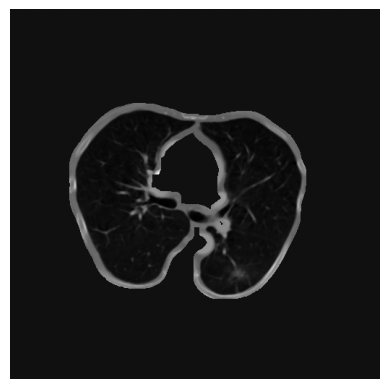

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap = 'gray')
plt.axis('off')
plt.show()

Folosesc torch pentru operatii cu tensori si F pentru interpolarea de la resize.

In [ ]:
import torch
import torch.nn.functional as F

O sa fac o functie pentru conversia din np array in tensor normalizat 0/1.

Definesc o functie to_tensor care primeste ca parametru variabila x de tip imagine Numpy si care va returna torch.Tensor.

Initial am pastrat tipul pixelilor ca float64 dar am avut o eroare de tipul failed to convert si am gasit o solutie aici:
https://stackoverflow.com/questions/58636087/tensorflow-valueerror-failed-to-convert-a-numpy-array-to-a-tensor-unsupporte
Asa ca, pentru compatibilitate, am transformat valorile arrayului in float32.

Apoi am aplicat normalizarea. M-am folosit de acest link: https://www.geeksforgeeks.org/python/how-to-normalize-an-numpy-array-so-the-values-range-exactly-between-0-and-1/
Pe scurt, ce e mai mic de valoarea medie se "aproximeaza" la 0 si ce e mai mare se "aproximeaza la 1". Am pus conditia aceea if pentru a evita situatia cand se imparte la 0 (daca imaginea are aceeasi valoare). In acest caz, s-ar pune zero uri peste tot.

La final se returneaza rezultatul transformarii din npy array in torch.



In [ ]:
def to_tensor(x: np.ndarray) -> torch.Tensor:
  x = x.astype(np.float32)
  x_min = x.min()
  x_max = x.max()
  if x_max > x_min:
    x = (x - x_min) / (x_max - x_min)
  else:
    x = np.zeros_like(x, dtype=np.float32)
  return torch.from_numpy(x)

Acum voi face functia de resize din 512x512 in 256x256 prin interpolare.

Functia resize primeste o variabila img_2d de tip tensor si size-ul dorit si returneaza un tensor.

Fiind o imagine 2d, ea e descrisa de 2 dimensiuni: inaltime si latime (height, width). Insa functia de interpolate asteapta o forma de tip [batch, channel, size, size], deci mai trebuie sa adaugam inca 2 dimensiuni. Pentru acest lucru voi folosi functia unsqueeze(0) de 2 ori pentru a adauga de 2 ori o dimensiune noua pe indexul 0.

Apoi am aplicat functia de resize unde se modifica height si width cu size-ul prestabilit. Am folosit acest link:
https://discuss.pytorch.org/t/how-to-do-image-resizing-with-bilinear-interpolation-using-torch-tensor-on-cuda/124894

La final, am eliminat cele 2 dimensiuni adaugate.

In [ ]:
def resize(img_2d: torch.Tensor, size=(256, 256)) -> torch.Tensor:
  x = img_2d.unsqueeze(0).unsqueeze(0)
  y=F.interpolate(x, size = size, mode = "bilinear", align_corners = False)
  return y.squeeze(0).squeeze(0)

Pentru test, am apelat cele 2 functii pentru imaginea sample, am afisat noua dimensiune pentru a verifica daca e identica cu cea ceruta si am afisat imaginea (am transformat tensorul inapoi in array pentru acest lucru).

noua dimensiune:  torch.Size([256, 256])


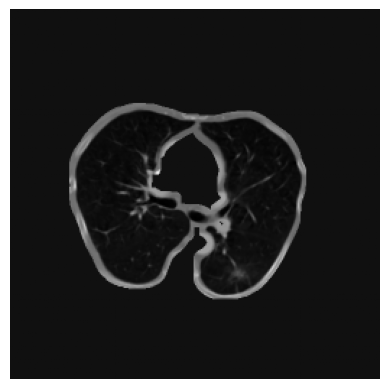

In [ ]:
image_converted = to_tensor(image)
image_resized = resize(image_converted, size=(256,256))

print("noua dimensiune: ", image_resized.shape)

plt.imshow(image_resized.numpy(), cmap='gray')
plt.axis('off')
plt.show()


Am gasit pe https://www.geeksforgeeks.org/computer-vision/feature-extraction-in-image-processing-techniques-and-applications/  un cod pentru canny edge detection pe care l am adaptat pentru imaginile mele.


Canny Edge Detector: Unlike the previous methods, the Canny Edge Detector is a multi-stage algorithm that provides more refined edge detection. It comprises several steps:
Gaussian Smoothing: The input image is convolved with a Gaussian kernel to reduce noise and smooth out the image.
Gradient Calculation: Sobel operators are applied to compute the gradient magnitude and direction at each pixel.
Non-maximum Suppression: This step helps thinning the detected edges by retaining only local maxima in the gradient magnitude along the direction of the gradient.
Double Thresholding: Pixels are classified as strong, weak, or non-edge pixels based on their gradient magnitudes. A high threshold determines strong edge pixels, while a low threshold identifies weak edge pixels.
Edge Tracking by Hysteresis: Weak edge pixels that are adjacent to strong edge pixels are considered as part of the edge. This helps in connecting discontinuous edge segments.
The Canny Edge Detector is known for its ability to detect a wide range of edges while suppressing noise and minimizing false detections

Mai jos e functia pentru edge detection:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_canny(img_tensor):
    img = img_tensor.numpy()

    # scalare 0-255
    img_uint8 = (img * 255).astype(np.uint8)

    edges = cv2.Canny(img_uint8, 150, 300)

    # suprapune muchiile peste imagine
    img_color = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)
    img_color[edges == 255] = [255, 0, 0]  # asta e culoarea edge urilor

    return img_uint8, edges, img_color

Apoi am facut o functie de afisare ca sa compare imaginea originala cu egdeurile si prin combinarea celor 2 un overlay peste imaginea originala

In [ ]:
def show_edges(original, edges, overlay):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Edges")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis('off')

    plt.show()

Apoi apelam functiile:

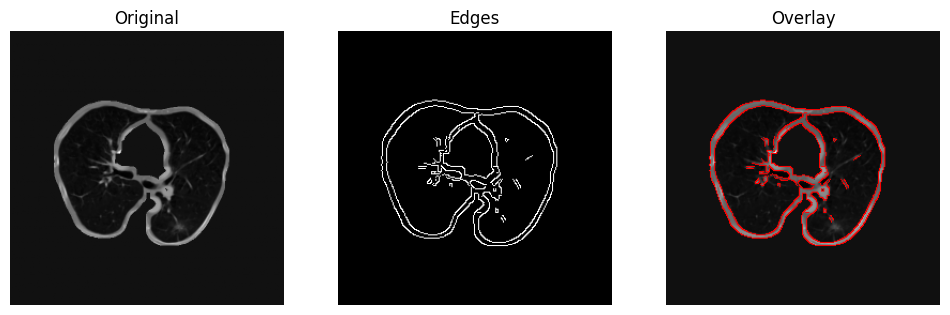

In [ ]:
original, edges, overlay = apply_canny(image_resized)
show_edges(original, edges, overlay)

Mai departe voi face o functie pentru a separa plamanul de fundal, pe care o vom folosi apoi pentru a limita mascarea in interiorul dreptunghiului. Pentru asta, am folosit mai multe functii din cv2. In primul rand am folosit functia dilate pentru a ma asigura ca edge-ul plamanului detectat cu canny este bine conturat. Apoi cu functia flood fill am umplut tot ce era conectat cu alb. Cu functia bitwise_not, am inversat efectul flood-ului, astfel ca fundalul devine negru si interiorul plamanului e alb.

In final, am combinat partea alba a interiorului plamanului si partea alba a conturului sau, obtinand o masca care acopera tot plamanul cu alb. Mai apoi am facut masca binara (1-plamanul si 0 exteriorul)

In [ ]:
import cv2
import numpy as np
import random

def generate_lung_mask(edges):
    # folosim o functie pentru ingrosarea conturului facut cu canny
    kernel = np.ones((5,5), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)

    # flood fill din margine - tot ce e conectat devine alb
    h, w = dilated.shape
    mask = np.zeros((h+2, w+2), np.uint8)
    flood = dilated.copy()
    cv2.floodFill(flood, mask, (0,0), 255)

    # inversam si fundalul devine negru, iar tot ce nu era fundal devine alb
    flood_inv = cv2.bitwise_not(flood)

    #imbinam interiorul plamanului cu conturul lui
    lung_mask = cv2.bitwise_or(dilated, flood_inv)

    # facem masca binara; 1- plamanul si 0-rest
    lung_mask = (lung_mask > 0).astype(np.uint8)

    return lung_mask

Functie pentru mascare

Mascarea consta in desenarea random a unor dreptunghiuri cu valoare 0 in imagini, urmand ca ele sa fie input, iar outputul sa fie imaginea reconstituita, fara dreptunghiuri. Folosindu-ma de masca creata am impus aparitia dreptunghiurilor doar in interiorul plamanului, iar prin tinerea evidentei pixelilor mastii aplicate, am mai impus conditia ca dreptunghiurile sa nu acopere mai mult de 80% din plaman, pentru a permite modelului sa invete mai eficient.

In [ ]:
def apply_random_rectangles(img_uint8, lung_mask, max_cover=0.8):
  #facem o copie la imagine si salvam dimensiunile
    img = img_uint8.copy()
    h, w = img.shape

    #numara nr de pixeli care constituie plamanul
    #cu covered tine evidenta cati pixeli sunt acoperiti
    lung_pixels = np.sum(lung_mask)
    covered = 0

    #de cate ori sa incerce sa acopere plamanul
    #astea sunt incercari care pot esua daca coordonatele generate sunt in afara plamanului
    #am modif 10 ca sa nu acopere mult plamanul, dar poate fi pus si mai mult
    attempts = 0
    max_attempts = 10

    #conditie sa nu acopere 80% din plaman
    #si sa nu fie depasit nr de incercari
    while covered < max_cover * lung_pixels and attempts < max_attempts:
        attempts += 1

        # genereaza dimensiuni random
        rect_w = random.randint(20, 60)
        rect_h = random.randint(20, 60)

        #genereaza pozitie random unde sa fie pus dreptunghiul
        x = random.randint(0, w - rect_w)
        y = random.randint(0, h - rect_h)

        #se creeaza dreptunghiul ca masca
        rect_mask = np.zeros_like(lung_mask)
        rect_mask[y:y+rect_h, x:x+rect_w] = 1

        # overlap e intersectia dintre dreptunghi si plaman
        overlap = rect_mask * lung_mask
        overlap_area = np.sum(overlap)

        # se accepta dreptunghiul daca e in plaman si nu depasteste 80%
        if overlap_area > 0:
            img[overlap == 1] = 0  # se adauga dreptunghiul
            lung_mask[overlap == 1] = 0  # marcheaza zona folosita
            covered += overlap_area #adauga pixelii acoperiti in cover

    return img

Functie de afisare

In [ ]:
def show_mask(original, edges, lung_mask, masked_img):
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.title("Edges")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.title("Lung Mask")
    plt.imshow(lung_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.title("Masked")
    plt.imshow(masked_img, cmap='gray')
    plt.axis('off')

    plt.show()

Acum testam functiile pe imaginea resized:

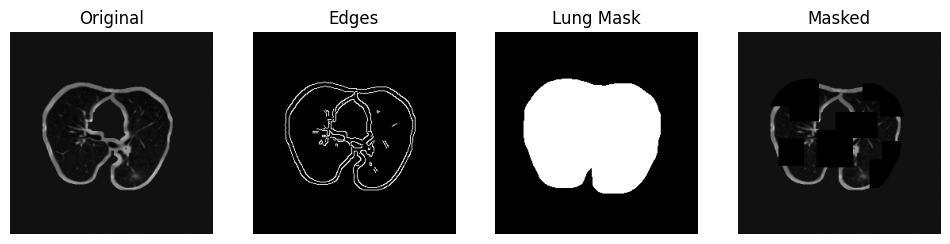

In [ ]:
lung_mask = generate_lung_mask(edges)
masked_img = apply_random_rectangles(original.copy(), lung_mask.copy())
show_mask(original, edges, lung_mask, masked_img)



Acum construiesc clasa ReconstructionDataset.

Pentru acest lucru, voi avea nevoie de Dataset din torch.utils.data

Definesc functia init - constructorul, care primeste setul de imagini si dimensiunea pentru resize.

Cu functia len voi obtine numarul de imagini din setul folosit.

Am creat functia getitem pentru a trece fiecare obiect prin functiile de mai devreme.

Modelul asteapta un tensor de forma [C, H, W] , deci am adaugat cu unsqueeze pentru a mai adauga un canal (pentru ca imaginile noastre sunt grayscale).

In [ ]:
from torch.utils.data import Dataset

class ReconstructionDataset(Dataset):
  def __init__(self, image_paths, size = (256, 256)):
    self.paths = image_paths
    self.size = size

  def __len__(self):
    return len(self.paths)

  def __getitem__(self, i):
    path = self.paths[i]
    img = np.load(path)
    img_converted = to_tensor(img)
    img_resized = resize(img_converted, size = self.size)

    original, edges, _ = apply_canny(img_resized)
    lung_mask = generate_lung_mask(edges)
    img_masked = apply_random_rectangles(original.copy(), lung_mask.copy())

    img_masked = to_tensor(img_masked)

    return img_masked.unsqueeze(0).float(), img_resized.unsqueeze(0).float()

am creat 3 obiecte de tip reconstructiondataset pentru fiecare set de date. apoi am facut cateva teste sa vad daca dimensiunea acestor obiecte si shape-ul imaginilor este in regula.

In [ ]:
train_dataset = ReconstructionDataset(train_paths, size=(256, 256))
val_dataset = ReconstructionDataset(val_paths, size=(256, 256))
test_dataset = ReconstructionDataset(test_paths, size=(256, 256))

In [ ]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

815 136 408


In [ ]:
x, y = train_dataset[0]

print("Input (masked):", x.shape, x.dtype, x.min().item(), x.max().item())
print("Target (original):", y.shape, y.dtype, y.min().item(), y.max().item())

Input (masked): torch.Size([1, 256, 256]) torch.float32 0.0 1.0
Target (original): torch.Size([1, 256, 256]) torch.float32 0.003775117453187704 0.9271665811538696


Am importat Dataloader pentru a imparti setul de date in batchuri (am ales sa pun cate 4 imagini intr-un batch) si in loc sa avem acces la imagini una cate una, vom primi cate 4 imagini simulan.Loader imi permite sa parcurg setul de date iterativ. DataLoader primeste datasetul, dimensiunea unui batch si setam shuffle = True ca sa avem datele amestecate inainte de formarea fiecarui batch. In for vom parcurge loaderul creat mai sus si vom afisa imaginea mascata si cea originala (resized, nu originala din dataset) care sunt returnate de clasa DataSet. Afisam acesti tensori care vor arata astfel : [4, 1, 256, 256] deoarece avem 4 imagini in batch, canalul e 1 pentru ca avem imagine alb-negru si dimensiunile 256x256, valabil pentru ambii tensori.Apoi am pus break pentru ca am vrut sa afisez doar primul batch, nu sa iterez tot setul momentan.
https://stackoverflow.com/questions/62461602/pytorch-dataset-dataloader-batching

In [ ]:
from torch.utils.data import DataLoader
loader_train = DataLoader(train_dataset, batch_size = 4, shuffle = True)
loader_val = DataLoader(val_dataset, batch_size = 4, shuffle = True)

testam dimensiunea sa fie potrivita pentru model:

In [ ]:
x, y = next(iter(loader_train))

print("Input batch shape:", x.shape)
print("Target batch shape:", y.shape)

Input batch shape: torch.Size([4, 1, 256, 256])
Target batch shape: torch.Size([4, 1, 256, 256])


Pentru implementarea modelului, o sa iau codul pentru clasa Unet de pe site-ul https://medium.com/@fernandopalominocobo/mastering-u-net-a-step-by-step-guide-to-segmentation-from-scratch-with-pytorch-6a17c5916114

In [ ]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

In [ ]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p

In [ ]:
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out

In [ ]:
!nvidia-smi

Wed Jul  1 06:17:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Pentru a putea trece mai departe la implementarea unei functii penmtru bucla de antrenare, o sa mut device-ul pe cuda. Apoi o sa iau modelul si un batch si o sa testez sa vad daca functioneaza cum trebuie.

In [ ]:
model = UNet(1, 1).to("cuda");

masked1, original1 = next(iter(loader_train));
masked1 = masked1.to("cuda");
original1 = original1.to("cuda");

output = model(masked1)
print(masked1.shape, output.shape, original1.shape)

torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])


Functie pentru salvare si pt load





In [ ]:
def save_checkpoint(model, optimizer, epoch, general_name):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
     }

    path =  models_path + f'/epoch_{epoch}_{general_name}.pth'
    print(f'Saved at path: {path}')
    torch.save(checkpoint, path)
    return path

def load_checkpoint(load_path, model, optimizer, device):
  dict_saved_values = torch.load(load_path, weights_only=True)

  model.load_state_dict(dict_saved_values['model_state_dict'])
  optimizer.load_state_dict(dict_saved_values['optimizer_state_dict'])
  epoch = dict_saved_values['epoch']

  print(f'Succesfully loaded model and optimizer from path: {load_path}')
  return model, optimizer, epoch

In [ ]:
!pip install pytorch-msssim

prep pentru train + cum incarc ceva de la checkpoint

In [ ]:
import torch
from torch import optim, nn
from tqdm import tqdm
import pickle as pkl
from torch.utils.tensorboard import SummaryWriter

device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels = 1, num_classes = 1).to(device)
learning_rate = 5e-5
optimizer = optim.AdamW(model.parameters(), lr = learning_rate)


# model, optimizer, epoch_offset = load_checkpoint('TU_STII_PATHUL', model, optimizer, device)
#Saved at path: /content/drive/MyDrive/ScoalaDeVara/Model/blabla_checkpoint_epoch_0.pth

epochs = 15

train_loader = loader_train
val_loader = loader_val
checkpoints_path = "/content/drive/MyDrive/ScoalaDeVara"
models_path = os.path.join(checkpoints_path, "Model")
writers_path = os.path.join(checkpoints_path, "Writers")

os.makedirs(models_path, exist_ok=True)
os.makedirs(writers_path, exist_ok=True)

base_dir = "/content/drive/MyDrive/ScoalaDeVara/Writers/experiment1"

writer = SummaryWriter(log_dir=base_dir)


In [ ]:
with torch.no_grad():

    x, _ = next(iter(loader_train))

    x = x.to(device)

    y = model(x)

    print("MIN:", y.min().item())
    print("MAX:", y.max().item())

MIN: -0.024263717234134674
MAX: -0.011964946985244751


In [ ]:
from pytorch_msssim import ssim
mse_loss = nn.MSELoss()

#def mse_function(pred, target):
    #return mse_loss(pred, target)

from pytorch_msssim import ssim

def mse_function(pred, target, alpha=0.999):
    mse = mse_loss(pred, target)
    ssim_loss = 1 - ssim(pred, target, data_range=1.0, size_average=True)
    return alpha * mse + (1 - alpha) * ssim_loss


def fc_loss(pred, target, alpha):
    #pred = torch.sigmoid(pred)
    mse = mse_loss(pred, target)

    ssim_term = 1 - ssim(
    pred,
    target,
    data_range=1.0,
    size_average=True
)
    loss = alpha * mse + (1 - alpha) * ssim_term
    return loss, mse, ssim_term

Functia pt validare

In [ ]:
def validate(model, val_loader, device, mse_function, writer, epoch, alpha=0.999):
    avg_loss = 0
    sample_count = 0

    model.eval()  # seteaza modelul in modul de evaluare
    with torch.no_grad():  # dezactiveaza calculul gradientilor pentru a grabi inferenta
        for val_data in val_loader:
            val_input, val_label = val_data
            val_input, val_label = val_input.to(device), val_label.to(device)
            val_output = model(val_input)
            #loss, mse, ssim_term = loss_function(
             #   val_output,
             #   val_label,
             #   alpha
             #   )

            loss = mse_function(val_output, val_label)
            avg_loss += loss.item()
            sample_count += 1

    avg_loss /= sample_count
    print(f"Validation loss: {avg_loss:.4f}")
    writer.add_scalar('Loss/validation', avg_loss, epoch)
    return avg_loss

In [ ]:
#validate(model, loader_val, device, mse_function, writer, 0, alpha=0.999)
validate(model, loader_val, device, mse_function, writer, 0)

Validation loss: 0.0584


0.05840463662410483

In [ ]:
def train(device, model, train_loader, val_loader, mse_function, optimizer, MAX_EPOCHS=15, VALIDATION_INTERVAL=2, EPOCH_OFFSET : int = 0):
    no_batches = len(train_loader)

    lr_val = optimizer.defaults['lr']
    wd_val = optimizer.defaults['weight_decay']

    # variables to get the best model
    best_loss = 1000
    best_metric_epoch = -1

    general_name = f'unet_adamw_lr{lr_val:.2e}_wd{wd_val:.2e}_mse'
    best_model_name = os.path.join(models_path, f"best_{general_name}.pth")

    #print(best_model_name)

    # evaluation metrics per epoch
    epoch_loss_values = []

    for epoch in range(1 + EPOCH_OFFSET, MAX_EPOCHS + 1):
        print("-" * 12)
        print(f"Epoch {epoch}/{MAX_EPOCHS}")

        # Turn model to "train" mode
        model.train()

        epoch_loss = 0
        for step, batch_data in enumerate(train_loader):
            step += 1

            train_input, label = batch_data
            train_input, label = train_input.to(device), label.to(device)

            optimizer.zero_grad() # Clear gradients
            output = model(train_input)

            loss = mse_function(output, label)

            #loss, mse, ssim_term = loss_function(output, label, alpha)
           # print(
            #    f"{step}/{no_batches} "
             #   f"loss={loss.item():.6f} "
               # f"mse={mse.item():.6f} "
               # f"ssim_term={ssim_term.item():.6f} "
               # )

            loss.backward() # Compute gradient

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, norm_type=2)
            optimizer.step() # Update model's parameters

            epoch_loss += loss.item()
            print(f"{step}/{no_batches}, train_loss: {loss.item():.4f}")

        epoch_loss /= step
        epoch_loss_values.append(epoch_loss)
        writer.add_scalar('Loss/train_mse', epoch_loss, epoch)

        print(f"epoch {epoch} average loss: {epoch_loss:.4f}")
        #alpha *= 0.995

        #print(f"alpha = {alpha:.6f}")
        #writer.add_scalar("Alpha", alpha, epoch)


        if epoch % VALIDATION_INTERVAL == 0:
            save_checkpoint(model, optimizer, epoch, f'checkpoint_{general_name}')

            val_loss = validate(model, val_loader, device, mse_function, writer, epoch)

            if val_loss < best_loss:
                best_loss = val_loss
                best_metric_epoch = epoch
                print("saved new best metric model!!!")

                save_checkpoint(model, optimizer, epoch, f'best_{general_name}')

            print(
                f"current epoch: {epoch},"
                f" current mean loss: {val_loss:.4f},"
                f" best mean loss: {best_loss:.4f},"
                f" at epoch: {best_metric_epoch}"
            )

    print(
        f"train completed, best loss: {best_loss:.4f}"
        f" at epoch: {best_metric_epoch}"
    )

    with open(os.path.join(models_path, f'best_{general_name}_metrics_evolution.pkl'), 'wb') as f:
        pkl.dump((epoch_loss_values), f)

    writer.close()

    return best_model_name


In [ ]:
train(device, model, loader_train, loader_val, mse_function, optimizer, MAX_EPOCHS=15, VALIDATION_INTERVAL=2, EPOCH_OFFSET = 0)

------------
Epoch 1/15
1/204, train_loss: 0.0322
2/204, train_loss: 0.0476
3/204, train_loss: 0.0345
4/204, train_loss: 0.0485
5/204, train_loss: 0.0329
6/204, train_loss: 0.0494
7/204, train_loss: 0.0462
8/204, train_loss: 0.0519
9/204, train_loss: 0.0506
10/204, train_loss: 0.0427
11/204, train_loss: 0.0330
12/204, train_loss: 0.0325
13/204, train_loss: 0.0272
14/204, train_loss: 0.0350
15/204, train_loss: 0.0351
16/204, train_loss: 0.0214
17/204, train_loss: 0.0410
18/204, train_loss: 0.0316
19/204, train_loss: 0.0306
20/204, train_loss: 0.0322
21/204, train_loss: 0.0182
22/204, train_loss: 0.0258
23/204, train_loss: 0.0277
24/204, train_loss: 0.0166
25/204, train_loss: 0.0156
26/204, train_loss: 0.0139
27/204, train_loss: 0.0127
28/204, train_loss: 0.0180
29/204, train_loss: 0.0059
30/204, train_loss: 0.0105
31/204, train_loss: 0.0155
32/204, train_loss: 0.0084
33/204, train_loss: 0.0073
34/204, train_loss: 0.0090
35/204, train_loss: 0.0118
36/204, train_loss: 0.0122
37/204, train

'/content/drive/MyDrive/ScoalaDeVara/Model/best_unet_adamw_lr5.00e-05_wd1.00e-02_mse.pth'

In [ ]:
#writer.add_graph

acum ca mi-a zis care e modelul cel mai bun, il incarc cu functia load:

In [ ]:
model, optimizer, last_epoch = load_checkpoint(
    "/content/drive/MyDrive/ScoalaDeVara/Model/epoch_12_best_unet_adamw_lr5.00e-05_wd1.00e-02_mse.pth",
    model,
    optimizer,
    device
)


Succesfully loaded model and optimizer from path: /content/drive/MyDrive/ScoalaDeVara/Model/epoch_12_best_unet_adamw_lr5.00e-05_wd1.00e-02_mse.pth


In [ ]:
from pytorch_msssim import ssim

def ssim_function(pred, target):

    return 1 - ssim(pred, target, data_range=1.0, size_average=True)

In [ ]:
def train_ssim(device, model, train_loader, val_loader, ssim_function,optimizer, MAX_EPOCHS=10, VALIDATION_INTERVAL=1, EPOCH_OFFSET=0):

    no_batches = len(train_loader)

    lr_val = optimizer.defaults['lr']
    wd_val = optimizer.defaults['weight_decay']

    best_loss = 1000
    best_metric_epoch = -1

    general_name = (
        f'unet_adamw_lr{lr_val:.2e}_wd{wd_val:.2e}_ssim_finetune'
    )

    best_model_name = os.path.join(
        models_path,
        f"best_{general_name}.pth"
    )

    epoch_loss_values = []

    for epoch in range(1 + EPOCH_OFFSET, MAX_EPOCHS + 1):

        print("-" * 12)
        print(f"Epoch {epoch}/{MAX_EPOCHS}")

        model.train()

        epoch_loss = 0

        for step, batch_data in enumerate(train_loader):
            step += 1

            train_input, label = batch_data
            train_input = train_input.to(device)
            label = label.to(device)

            optimizer.zero_grad()

            output = model(train_input)

            loss = ssim_function(output, label)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1,
                norm_type=2
            )

            optimizer.step()

            epoch_loss += loss.item()

            print(
                f"{step}/{no_batches}, "
                f"train_loss: {loss.item():.4f}"
            )

        epoch_loss /= step

        epoch_loss_values.append(epoch_loss)

        writer.add_scalar(
            'Loss/train_ssim',
            epoch_loss,
            epoch
        )

        print(
            f"epoch {epoch} average loss: "
            f"{epoch_loss:.4f}"
        )

        if epoch % VALIDATION_INTERVAL == 0:

            save_checkpoint(
                model,
                optimizer,
                epoch,
                f'checkpoint_{general_name}'
            )

            val_loss = validate(
                model,
                val_loader,
                device,
                ssim_function,
                writer,
                epoch
            )

            if val_loss < best_loss:

                best_loss = val_loss
                best_metric_epoch = epoch

                print("saved new best metric model!!!")

                save_checkpoint(
                    model,
                    optimizer,
                    epoch,
                    f'best_{general_name}'
                )

            print(
                f"current epoch: {epoch}, "
                f"current mean loss: {val_loss:.4f}, "
                f"best mean loss: {best_loss:.4f}, "
                f"at epoch: {best_metric_epoch}"
            )

    print(
        f"train completed, best loss: {best_loss:.4f} "
        f"at epoch: {best_metric_epoch}"
    )

    with open(
        os.path.join(
            models_path,
            f'best_{general_name}_metrics_evolution.pkl'
        ),
        'wb'
    ) as f:

        pkl.dump(epoch_loss_values, f)

    writer.close()

    return best_model_name

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

train_ssim(
    device,
    model,
    loader_train,
    loader_val,
    ssim_function,
    optimizer,
    MAX_EPOCHS=10,
    VALIDATION_INTERVAL=1
)

------------
Epoch 1/10
1/204, train_loss: 0.0633
2/204, train_loss: 0.0451
3/204, train_loss: 0.0437
4/204, train_loss: 0.0555
5/204, train_loss: 0.0806
6/204, train_loss: 0.0457
7/204, train_loss: 0.0484
8/204, train_loss: 0.0474
9/204, train_loss: 0.0695
10/204, train_loss: 0.0555
11/204, train_loss: 0.0275
12/204, train_loss: 0.0419
13/204, train_loss: 0.0388
14/204, train_loss: 0.0593
15/204, train_loss: 0.0720
16/204, train_loss: 0.0717
17/204, train_loss: 0.0662
18/204, train_loss: 0.0400
19/204, train_loss: 0.0615
20/204, train_loss: 0.0660
21/204, train_loss: 0.0414
22/204, train_loss: 0.0239
23/204, train_loss: 0.0444
24/204, train_loss: 0.0387
25/204, train_loss: 0.0490
26/204, train_loss: 0.0419
27/204, train_loss: 0.0734
28/204, train_loss: 0.1008
29/204, train_loss: 0.0397
30/204, train_loss: 0.0413
31/204, train_loss: 0.0421
32/204, train_loss: 0.0333
33/204, train_loss: 0.0341
34/204, train_loss: 0.0311
35/204, train_loss: 0.0358
36/204, train_loss: 0.0945
37/204, train

'/content/drive/MyDrive/ScoalaDeVara/Model/best_unet_adamw_lr1.00e-05_wd1.00e-02_ssim_finetune.pth'

In [ ]:
model2, optimizer, last_epoch = load_checkpoint(
    "/content/drive/MyDrive/ScoalaDeVara/Model/epoch_9_best_unet_adamw_lr1.00e-05_wd1.00e-02_ssim_finetune.pth",
    model,
    optimizer,
    device
)


Succesfully loaded model and optimizer from path: /content/drive/MyDrive/ScoalaDeVara/Model/epoch_9_best_unet_adamw_lr1.00e-05_wd1.00e-02_ssim_finetune.pth


In [ ]:
#writer.add_graph

vizualizare:

In [ ]:
#model2.eval()
model.eval()
masked, target = next(iter(loader_val))
masked = masked.to(device)

with torch.no_grad():
  #pred = model2(masked)
  pred = model(masked)

masked = masked.cpu()
target = target.cpu()
pred = pred.cpu()


dummy = torch.randn(1, 1, 256, 256).to(device)
#writer.add_graph(model2, dummy)
writer.add_graph(model, dummy)



In [ ]:
model2.eval()
masked, target = next(iter(loader_val))
masked = masked.to(device)

with torch.no_grad():
  pred = model2(masked)

masked = masked.cpu()
target = target.cpu()
pred = pred.cpu()


dummy = torch.randn(1, 1, 256, 256).to(device)
writer.add_graph(model2, dummy)


NameError: name 'model2' is not defined

In [ ]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Input")
    plt.imshow(masked[i,0], cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Target")
    plt.imshow(target[i,0], cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred[i,0], cmap='gray')
    plt.axis('off')

    plt.show()

Succesfully loaded model and optimizer from path: /content/drive/MyDrive/ScoalaDeVara/Model/epoch_12_best_unet_adamw_lr5.00e-05_wd1.00e-02_mse.pth
Succesfully loaded model and optimizer from path: /content/drive/MyDrive/ScoalaDeVara/Model/epoch_9_best_unet_adamw_lr1.00e-05_wd1.00e-02_ssim_finetune.pth


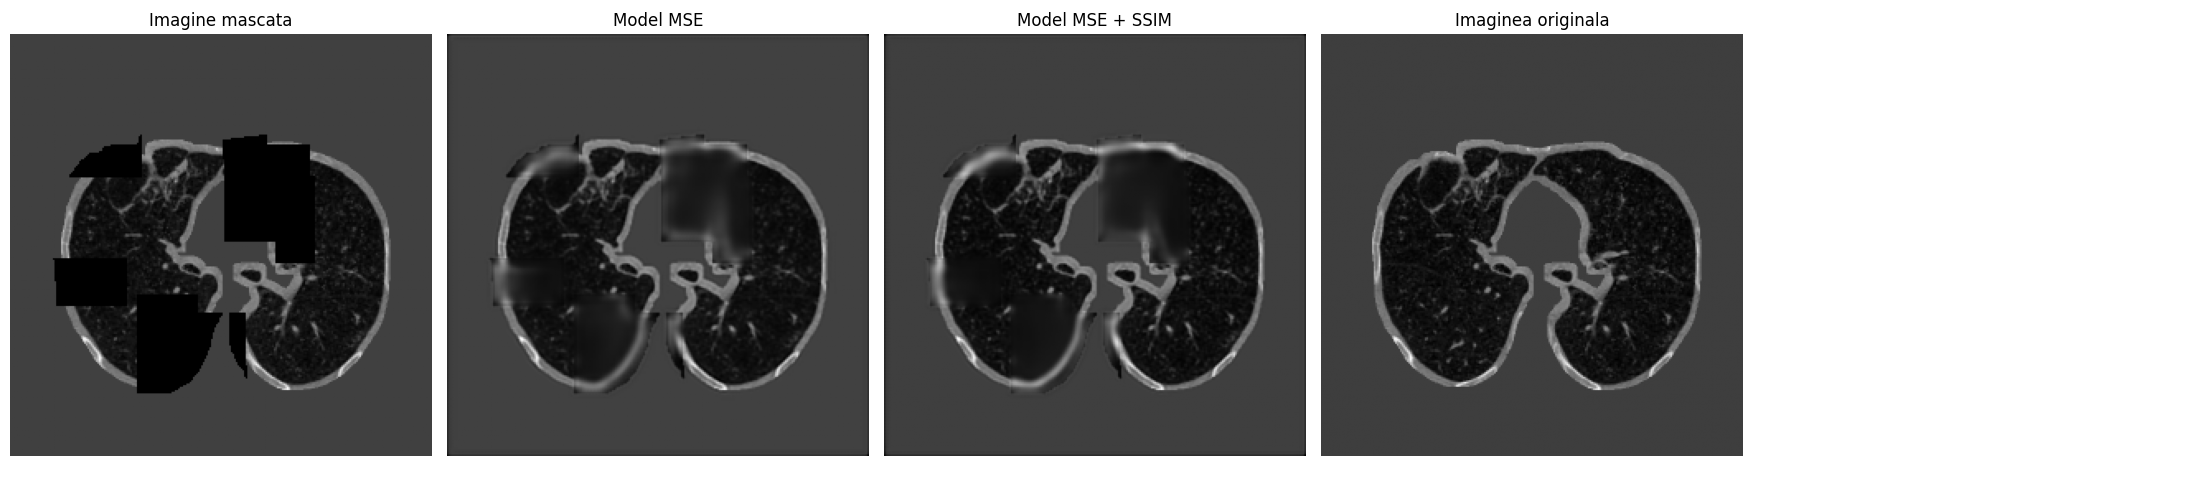

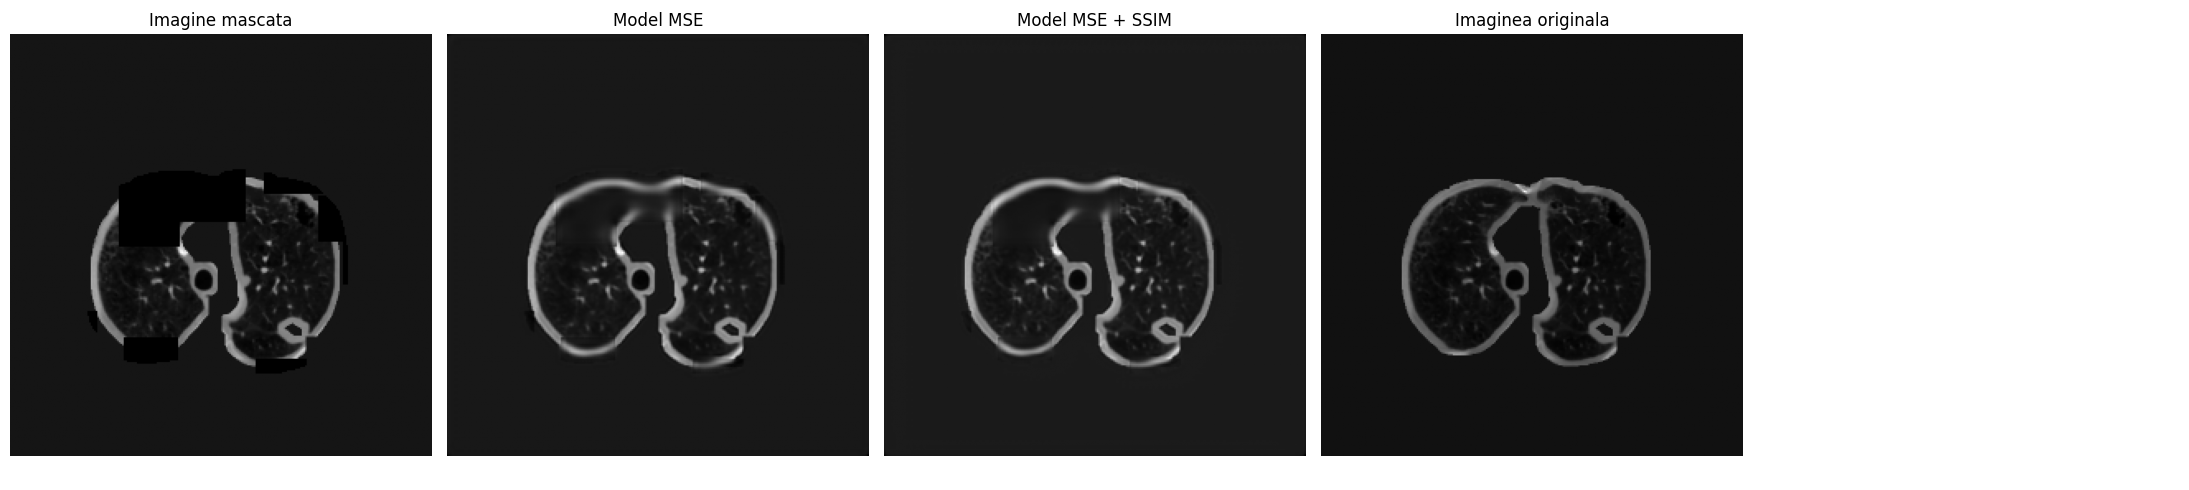

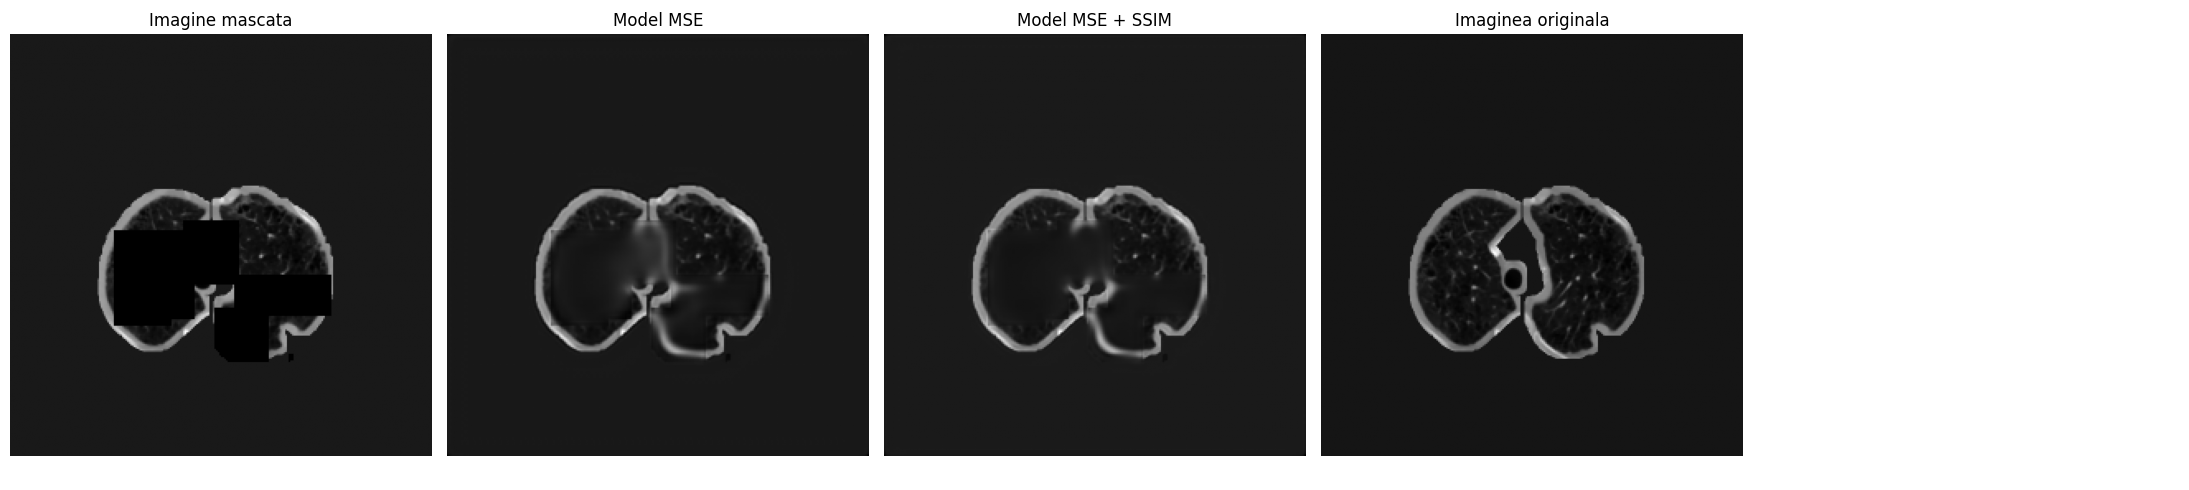

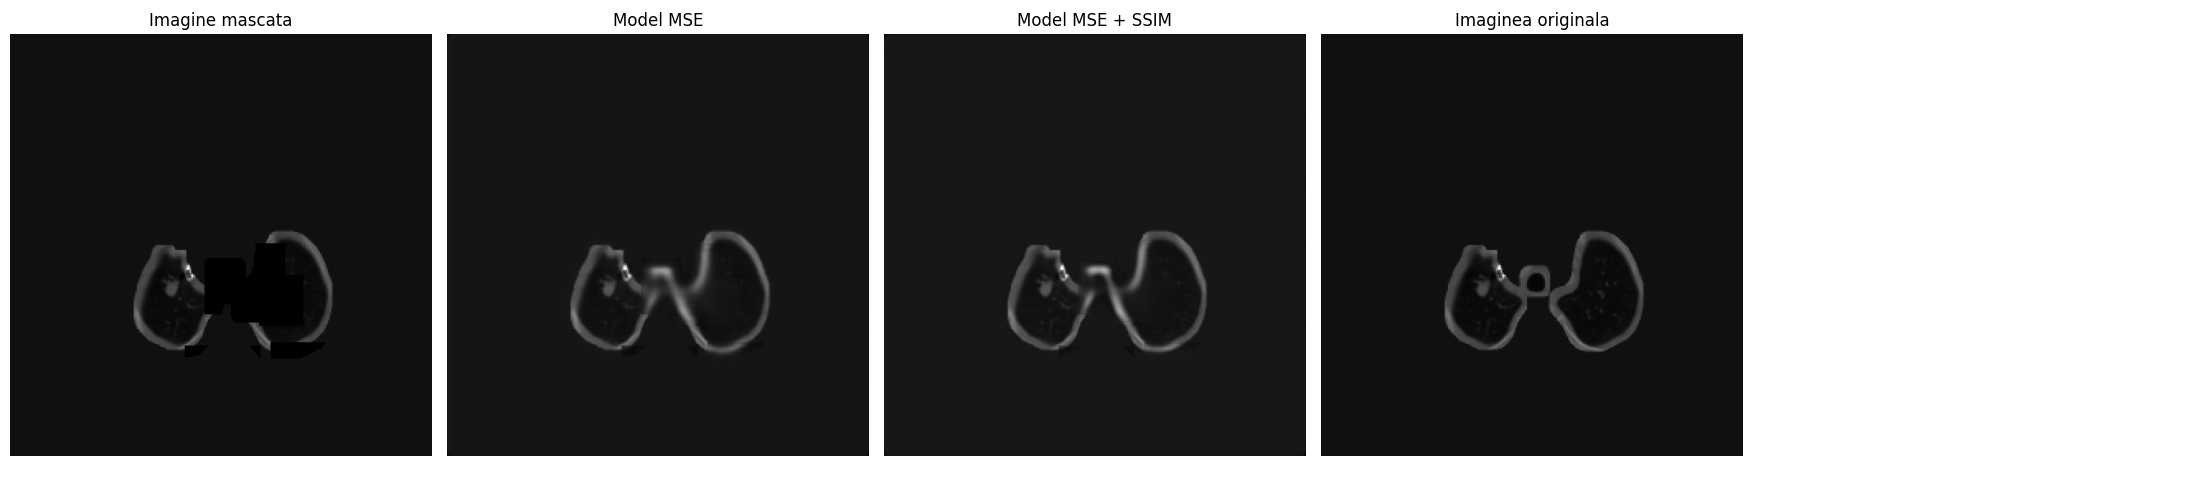

In [ ]:
#demo
model_mse = UNet(
    in_channels=1,
    num_classes=1
).to(device)

model_ssim = UNet(
    in_channels=1,
    num_classes=1
).to(device)

optimizer = optim.AdamW(model_mse.parameters(), lr=5e-5)

model_mse, _, _ = load_checkpoint(
    "/content/drive/MyDrive/ScoalaDeVara/Model/epoch_12_best_unet_adamw_lr5.00e-05_wd1.00e-02_mse.pth",
    model_mse,
    optimizer,
    device
)

model_ssim, _, _ = load_checkpoint(
   "/content/drive/MyDrive/ScoalaDeVara/Model/epoch_9_best_unet_adamw_lr1.00e-05_wd1.00e-02_ssim_finetune.pth",
    model_ssim,
    optimizer,
    device
)

model_mse.eval()
model_ssim.eval()

masked, target = next(iter(loader_val))

masked_gpu = masked.to(device)

with torch.no_grad():

    pred_mse = model_mse(masked_gpu)
    pred_ssim = model_ssim(masked_gpu)

pred_mse = pred_mse.cpu()
pred_ssim = pred_ssim.cpu()

for i in range(4):

    fig, ax = plt.subplots(1,5, figsize=(22,5))

    ax[0].imshow(masked[i][0], cmap='gray')
    ax[0].set_title("Imagine mascata")

    ax[1].imshow(pred_mse[i][0], cmap='gray')
    ax[1].set_title("Model MSE")

    ax[2].imshow(pred_ssim[i][0], cmap='gray')
    ax[2].set_title("Model MSE + SSIM")



    ax[3].imshow(target[i][0], cmap='gray')
    ax[3].set_title("Imaginea originala")

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()